In [1]:
import numpy as np
import math
import pygad
import statistics
import pandas as pd
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    else:
        value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values)
    mask_no = (values < a) & (diffs < a)
    mask_yes = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

def evaluate_params(X, y, params):
    n_features = X.shape[1]
    value = np.abs(X[:, 0] - params[5])
    i = 6
    for j in range(n_features - 1):
        diff = np.abs(X[:, j+1] - params[i])
        value = classification_vec(value, diff,
                                   params[0], params[1], params[2], params[3])
        i += 1

    error = np.exp2(np.abs(value - y))
    calc_class = (value >= params[0]).astype(int)
    target_class = (y >= params[0]).astype(int)
    mean_error = np.mean(error)
    f1 = f1_score(target_class, calc_class, zero_division=0)

    return value, error, calc_class, target_class, mean_error, f1

def run_ga_on_fold(X_train_fold, y_train_fold):
    n_features = X_train_fold.shape[1]

    def fitness_func(ga_instance, solution, solution_idx):
        try:
            param = np.array(solution, dtype=float)
            value = np.abs(X_train_fold[:, 0] - param[5])
            i = 6
            for j in range(n_features - 1):
                diff = np.abs(X_train_fold[:, j+1] - param[i])
                value = classification_vec(value, diff,
                                           param[0], param[1], param[2], param[3])
                i += 1

            error = np.exp2(np.abs(value - y_train_fold))
            fitness1 = 1.0 / (math.sqrt(np.mean(error)) + 1e-8)

            calc_class = (value >= param[0]).astype(int)
            target_class = (y_train_fold >= param[0]).astype(int)
            fitness2 = f1_score(target_class, calc_class, zero_division=0)

            if np.isnan(fitness1) or np.isnan(fitness2):
                return 0

            return param[4]*fitness1 + (1-param[4])*fitness2

        except Exception as e:
            print(f"Fitness calculation failed: {e}")
            return 0

    ga_instance = pygad.GA(
        num_generations=60,
        num_parents_mating=12,
        fitness_func=fitness_func,
        sol_per_pop=24,
        num_genes=14,
        init_range_low=0,
        init_range_high=1,
        parent_selection_type="tournament",
        K_tournament=3,
        keep_parents=2,
        crossover_type="single_point",
        mutation_type="random",
        mutation_percent_genes=15,
        gene_space=[
            {'low': 0.3, 'high': 0.7},
            {'low': 0, 'high': 3},
            {'low': 0, 'high': 3},
            {'low': 0, 'high': 1},
            {'low': 0, 'high': 1},
            *([[0, 1]] * 9)
        ]
    )

    ga_instance.run()
    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    return np.array(solution, dtype=float), solution_fitness, solution_idx

def calculate_param_using_gen_alg(data: pd.DataFrame, n_splits: int = 10):
    df = data.copy()
    X = df.iloc[:, :-1].to_numpy()
    y = df.iloc[:, -1].to_numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_results = []  

    print(f"{n_splits}-fold cross-validation")
    print("=" * 60)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
        print(f"\n--- Fold {fold_idx}/{n_splits} ---")

        X_train_fold = X[train_index]
        y_train_fold = y[train_index]
        X_val_fold   = X[val_index]
        y_val_fold   = y[val_index]

        best_params, solution_fitness, solution_idx = run_ga_on_fold(X_train_fold, y_train_fold)

        (train_values, train_errors,
         train_calc_class, train_target_class,
         train_mean_error, train_f1) = evaluate_params(X_train_fold, y_train_fold, best_params)

        (val_values, val_errors,
         val_calc_class, val_target_class,
         val_mean_error, val_f1) = evaluate_params(X_val_fold, y_val_fold, best_params)

        print(f"  Train -> Mean Error: {train_mean_error:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   -> Mean Error: {val_mean_error:.4f}  | F1: {val_f1:.4f}")
        print(f"  Params -> a={best_params[0]:.4f}, kappa={best_params[1]:.4f}, "
              f"lambda={best_params[2]:.4f}, gamma={best_params[3]:.4f}")

        fold_result = {
            "fold": fold_idx,
            "train_indices": train_index.tolist(),
            "val_indices": val_index.tolist(),
            "train_size": len(train_index),
            "val_size": len(val_index),

            "best_params": best_params,
            "a": best_params[0],
            "kappa": best_params[1],
            "lambda": best_params[2],
            "gamma": best_params[3],
            "fitness_weight": best_params[4],
            "binary_params": best_params[5:].tolist(),
            "solution_fitness": solution_fitness,
            "solution_idx": solution_idx,

            "train_mean_error": train_mean_error,
            "train_f1": train_f1,
            "train_values": train_values.tolist(),
            "train_errors": train_errors.tolist(),
            "train_calc_class": train_calc_class.tolist(),
            "train_target_class": train_target_class.tolist(),

            "val_mean_error": val_mean_error,
            "val_f1": val_f1,
            "val_values": val_values.tolist(),
            "val_errors": val_errors.tolist(),
            "val_calc_class": val_calc_class.tolist(),
            "val_target_class": val_target_class.tolist(),

            "X_train_fold": X_train_fold.tolist(),
            "y_train_fold": y_train_fold.tolist(),
            "X_val_fold": X_val_fold.tolist(),
            "y_val_fold": y_val_fold.tolist(),
        }
        cv_results.append(fold_result)

    print("\n" + "=" * 60)
    print("=" * 60)

    summary_df = pd.DataFrame([{
        "Fold":            r["fold"],
        "Train Size":      r["train_size"],
        "Val Size":        r["val_size"],
        "Train MeanError": round(r["train_mean_error"], 4),
        "Train F1":        round(r["train_f1"], 4),
        "Val MeanError":   round(r["val_mean_error"], 4),
        "Val F1":          round(r["val_f1"], 4),
        "a":               round(r["a"], 4),
        "kappa":           round(r["kappa"], 4),
        "lambda":          round(r["lambda"], 4),
        "gamma":           round(r["gamma"], 4),
        "GA Fitness":      round(r["solution_fitness"], 4),
    } for r in cv_results])

    print(summary_df.to_string(index=False))
    print(f"\nMean Val F1:         {summary_df['Val F1'].mean():.4f} ± {summary_df['Val F1'].std():.4f}")
    print(f"Mean Val Mean Error: {summary_df['Val MeanError'].mean():.4f} ± {summary_df['Val MeanError'].std():.4f}")

    best_fold_idx = summary_df["Val F1"].idxmax()
    best_fold_result = cv_results[best_fold_idx]
    print(f"\nNajbolji fold: Fold {best_fold_result['fold']} "
          f"(Val F1 = {best_fold_result['val_f1']:.4f})")

    return cv_results, best_fold_result, summary_df

In [3]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [4]:
def print_attr_coef(sol_param):
  coeficients = []
  for i in sol_param:
    if i == 1:
      pom = '1-decreasing'
      coeficients.append(pom)
    elif i == 0:
      pom = '0-increasing'
      coeficients.append(pom)

  name_columns = data.drop(columns=['target']).columns

  merge_list = name_columns + [': '] + coeficients
  for list in merge_list:
    print(list)

In [5]:
def view_chart(a, kappa, lam):

    plt.figure(figsize=(3, 3))
    plt.subplot(111)
    y = np.arange(0, 1, 0.05)
    x = [a] * len(y)
    plt.scatter(x, y, c = 'black', s = 1)

    x = np.arange(0, 1, 0.05)
    y = [a] * len(x)
    plt.scatter(x, y, c = 'black', s = 1)

    y1 = np.arange(a, 1.0, 0.001)
    b=1
    x1 = 1-((1-a)**kappa-(1-y1)**kappa)**(1/kappa)
    plt.plot(x1, y1, c = 'red')
    plt.fill_between(y1,x1, b, color='red')

    y2 = np.arange(0, a, 0.01)
    x2 = ((a**lam)-(y2**lam))**(1/lam)
    plt.plot(y2, x2, c = 'green')
    plt.fill_between(y2,x2,color='green')

    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.annotate('D', xy=(a, a), xytext=(a + 0.2, a + 0.2), fontsize=12)
    plt.annotate('C', xy=(a, a), xytext=(a - 0.3, a - 0.3), fontsize=12)
    plt.annotate('Avg', xy=(a, a), xytext=(a - 0.3, a + 0.2), fontsize=12)
    plt.annotate('Avg', xy=(a, a), xytext=(a + 0.2, a - 0.3), fontsize=12)

    plt.annotate('a', xy=(a, a), xytext=(a - 0.04, a - 0.63), fontsize=12)
    plt.annotate('a', xy=(a, a), xytext=(a - 0.63, a - 0.04), fontsize=12)

    return (plt)

In [6]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value, average= 'macro'))
  print('Precision = ', precision_score(target_values, value, average= 'macro'))
  print('Recall = ', recall_score(target_values, value, average= 'macro'))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

In [7]:
df = sns.load_dataset('titanic')
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'sibsp', 'parch', 'alone', 'embarked'])

df['age'] = df['age'].fillna(df['age'].median())
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['fare'] = np.where(df['fare'] > upper_bound, upper_bound, 
             np.where(df['fare'] < lower_bound, lower_bound, df['fare']))
df = df.rename(columns={'survived': 'target'})

df_final = df.iloc[:, list(range(1, df.shape[1])) + [0]]

X_train, X_test = train_test_split(df_final, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_final.columns)

print(X_train_scaled.head())

   pclass  sex       age      fare  target
0     0.0  0.0  0.566474  0.434224     0.0
1     0.5  0.0  0.283740  0.198067     0.0
2     1.0  0.0  0.396833  0.120745     0.0
3     1.0  0.0  0.321438  0.119666     0.0
4     1.0  1.0  0.070118  0.476503     0.0


In [10]:
start_time = time.time()
cv_results, best_fold_result, summary_df = calculate_param_using_gen_alg(X_train_scaled)
print('time:', (time.time()-start_time)/60)

10-fold cross-validation

--- Fold 1/10 ---
  Train -> Mean Error: 1.2227 | F1: 0.6027
  Val   -> Mean Error: 1.1828  | F1: 0.7843
  Params -> a=0.3086, kappa=2.2279, lambda=0.2642, gamma=0.9627

--- Fold 2/10 ---
  Train -> Mean Error: 1.2190 | F1: 0.6319
  Val   -> Mean Error: 1.2092  | F1: 0.6341
  Params -> a=0.3074, kappa=2.6808, lambda=0.3673, gamma=0.9696

--- Fold 3/10 ---
  Train -> Mean Error: 1.2214 | F1: 0.6445
  Val   -> Mean Error: 1.2304  | F1: 0.6111
  Params -> a=0.3490, kappa=2.7831, lambda=0.4696, gamma=0.9342

--- Fold 4/10 ---
  Train -> Mean Error: 1.2124 | F1: 0.6346
  Val   -> Mean Error: 1.2638  | F1: 0.5778
  Params -> a=0.3027, kappa=2.4638, lambda=1.9735, gamma=0.9930

--- Fold 5/10 ---
  Train -> Mean Error: 1.2173 | F1: 0.6313
  Val   -> Mean Error: 1.2393  | F1: 0.6000
  Params -> a=0.3378, kappa=2.2296, lambda=0.2967, gamma=0.9735

--- Fold 6/10 ---
  Train -> Mean Error: 1.2152 | F1: 0.6301
  Val   -> Mean Error: 1.2783  | F1: 0.6154
  Params -> a=0.356

Accuracy score =  0.6966292134831461
F1 =  0.6392298164621101
Precision =  0.63695038321904
Recall =  0.6845108695652173


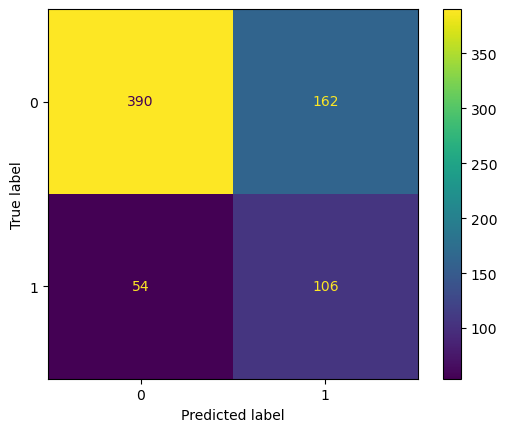

In [11]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']< best_fold_result['a'])else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target']].values)

In [12]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
     pclass  sex       age      fare  target  calc_value
0       1.0  0.0  0.346569  0.232284     1.0    0.026803
1       0.5  0.0  0.384267  0.159977     0.0    0.003414
2       1.0  0.0  0.246042  0.120745     0.0    0.003023
3       0.5  1.0  0.070118  0.502785     1.0    0.419043
4       1.0  1.0  0.170646  0.171278     1.0    0.322517
..      ...  ...       ...       ...     ...         ...
174     1.0  0.0  0.208344  0.108556     0.0    0.001233
175     1.0  0.0  0.346569  0.110079     0.0    0.006339
176     1.0  1.0  0.472229  0.478217     1.0    1.000000
177     0.5  1.0  0.208344  0.159977     1.0    0.366205
178     1.0  1.0  0.044986  0.254440     1.0    0.141999

[179 rows x 6 columns]
γ =  0
λ =  0
κ =  0
a =  0
Mean squared error =  0.3081
Root Mean Square Error =  0.5551


In [13]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']< best_fold_result['a'])else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< best_fold_result['a'])else 1, axis=1)

In [14]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.6536312849162011
F1 =  0.6081214689265537
Precision =  0.6478114478114478
Recall =  0.612998712998713


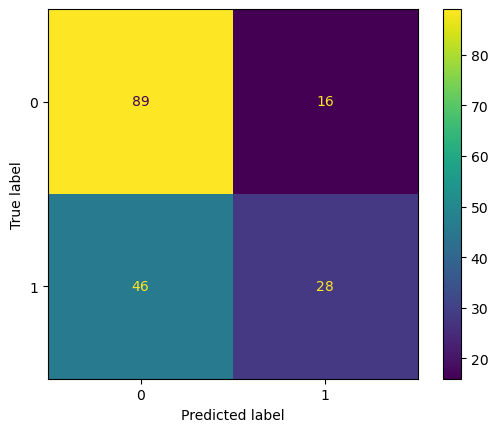

In [15]:
calculate_tests(target_values, value)